# Customer Segmentation — Clustering Analysis
**Role:** Data Analyst – Clustering Analysis
**Project:** Customer Churn Analysis for a Telecommunications Company
**Stage:** Stage 2 — Data Preparation and Modeling

This notebook covers the full clustering workflow for this role:
1. Load the preprocessed data handed off by the Data Engineer
2. Select the features to cluster on (`tenure`, `MonthlyCharges`)
3. Use the **elbow method** to find the optimal number of clusters (k)
4. Confirm the choice with a **silhouette score** check
5. Train the final K-Means model
6. Interpret and label the resulting clusters
7. Visualise the segments

## 1. Imports

- `pandas` / `numpy` — data handling
- `sklearn.cluster.KMeans` — the clustering algorithm itself
- `sklearn.metrics.silhouette_score` — a second way to sanity-check the number of clusters
- `matplotlib` — visualising the elbow curve and the final clusters

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## 2. Load the data

Data has been processed by removing duplicate rows, encoding
categorical variables (one-hot encoding), scaling the numeric features, and splitting into
train/test sets. We just load what was handed off.

We load `X_train` and `y_train` together — `X` has the features, `y` has the churn label
(`0` = did not churn, `1` = churn). Clustering itself only uses `X` (it's unsupervised), but
we bring `y_train` along so we can check the churn rate *within* each cluster afterwards —
that's what turns "four groups of dots" into an actionable business insight.

In [2]:
X_train = pd.read_csv('ATS_X_train_scaled.csv')
X_test = pd.read_csv('ATS_X_test_scaled.csv')
y_train = pd.read_csv('ATS_y_train.csv')
y_test = pd.read_csv('ATS_y_test.csv')

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
X_train.head()

X_train shape: (5392, 10)
X_test shape: (1349, 10)


,SeniorCitizen,tenure,MonthlyCharges,gender_Male,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,Contract_One year,Contract_Two year
0,-0.450593,0.944773,1.486201,-1.013443,1.511887,0.338734,1.164308,1.130056,-0.521534,-0.581348
1,-0.450593,1.232687,-0.234838,-1.013443,-0.661425,0.338734,-0.858879,-0.884912,-0.521534,-0.581348
2,-0.450593,0.821382,0.946267,-1.013443,-0.661425,0.338734,-0.858879,-0.884912,1.917419,-0.581348
3,-0.450593,1.602861,1.621184,0.986735,1.511887,0.338734,-0.858879,-0.884912,-0.521534,-0.581348
4,-0.450593,-0.988360,0.338842,0.986735,-0.661425,0.338734,-0.858879,-0.884912,-0.521534,-0.581348


## 3. Select the clustering features

The handed-off dataset has more columns than **tenure and monthly charges** (one-hot encoded
`gender`, `Contract`, etc.) because those were needed for the ANN model — but for
*this* clustering task we deliberately narrow down to just the two features we were asked
to segment on.

In [3]:
X_cluster = X_train[['tenure', 'MonthlyCharges']].copy()

# Sanity check: confirm both features are standardized
X_cluster.describe()

,tenure,MonthlyCharges
count,5.392000e+03,5.392000e+03
mean,-6.588861e-18,1.502260e-16
std,1.000093e+00,1.000093e+00
min,-1.358535e+00,-1.618418e+00
25%,-9.472296e-01,-8.085174e-01
50%,-1.246196e-01,1.701124e-01
75%,9.447734e-01,8.112837e-01
max,1.602861e+00,1.789914e+00


## 4. Elbow method — finding the optimal k

**The idea:** for a range of candidate cluster counts (k = 1 to 10), fit a K-Means model
and record the **WCSS** (Within-Cluster Sum of Squares, also called *inertia*), a measure
of how tightly packed the points are within each cluster. WCSS always decreases as k
increases (more clusters can always fit the data more tightly), so we're not looking for
the lowest value; we're looking for the **"elbow"**: the point where adding another
cluster stops buying you much improvement.

- `init='k-means++'` — a smarter way of placing the initial cluster centers (avoids bad
  random starts)
- `n_init=10` — runs the algorithm 10 times with different starting points and keeps the
  best result, since K-Means can converge to different local optima
- `random_state=42` — makes the result reproducible

In [4]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_cluster)
    wcss.append(km.inertia_)

for k, w in zip(k_range, wcss):
    print(f"k={k}: WCSS={w:.2f}")

k=1: WCSS=10784.00
k=2: WCSS=6099.30
k=3: WCSS=3556.66
k=4: WCSS=2242.08
k=5: WCSS=1841.15
k=6: WCSS=1517.29
k=7: WCSS=1228.51
k=8: WCSS=1060.43
k=9: WCSS=916.17
k=10: WCSS=803.36


Plotting this makes the elbow visible. We also print the percentage drop at each step,
that's often easier to read precisely than eyeballing a bend in a curve.

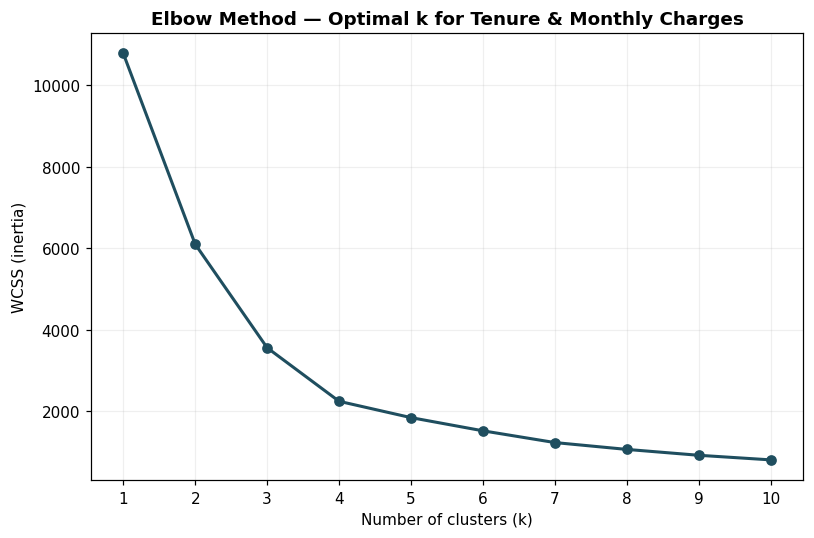

k, WCSS, % drop from previous k
1, 10784.00, -
2, 6099.30, 43.4%
3, 3556.66, 41.7%
4, 2242.08, 37.0%
5, 1841.15, 17.9%
6, 1517.29, 17.6%
7, 1228.51, 19.0%
8, 1060.43, 13.7%
9, 916.17, 13.6%
10, 803.36, 12.3%


In [5]:
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(list(k_range), wcss, marker='o', color='#1F4E5F', linewidth=2)
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('WCSS (inertia)')
ax.set_title('Elbow Method — Optimal k for Tenure & Monthly Charges', fontweight='bold')
ax.set_xticks(list(k_range))
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=160)
plt.show()

# Percentage drop at each step, to make the "elbow" objective rather than a guess
print("k, WCSS, % drop from previous k")
prev = None
for k, w in zip(k_range, wcss):
    pct = f"{(prev - w) / prev * 100:.1f}%" if prev else "-"
    print(f"{k}, {w:.2f}, {pct}")
    prev = w

**Reading the result:** the percentage drop is large through k=2→4 (43% → 42% → 37%),
then falls off sharply after k=4 (down to 18% and below). That flattening is the elbow —
it tells us k=4 is where extra clusters stop being worth the added complexity.

## 5. Silhouette score — a second opinion

The elbow method is a bit subjective (you're eyeballing a bend in a curve). The
**silhouette score** gives a more objective second check: for each point, it compares how
close it is to its own cluster vs. the nearest other cluster. The score ranges from -1 to 1
— higher is better (tighter, better-separated clusters).

We check a range around our elbow candidate (k=2 to 7) to confirm k=4 isn't just an
artifact of the elbow chart.

In [6]:
silhouette_scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    cluster_labels = km.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, cluster_labels, sample_size=2000, random_state=42)
    silhouette_scores[k] = score
    print(f"k={k}: silhouette score={score:.4f}")

k=2: silhouette score=0.4063


k=3: silhouette score=0.4431
k=4: silhouette score=0.4593
k=5: silhouette score=0.4167


k=6: silhouette score=0.4176


k=7: silhouette score=0.4223


**Result:** the silhouette score peaks at **k=4** (≈0.459) and declines for k=5 and
beyond. This agrees with the elbow method, so we can be confident k=4 is a well-supported
choice, not just a visual guess.

## 6. Train the final K-Means model (k=4)

Now we train the model we're actually going to use, attach the resulting cluster label
back onto each customer, and bring in the churn label so we can see how churn varies
across segments.

In [7]:
kmeans_final = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_cluster)

results = X_cluster.copy()
results['cluster'] = cluster_labels
results['Churn'] = y_train['Churn'].values

print("Cluster centers (standardized tenure, MonthlyCharges):")
for i, center in enumerate(kmeans_final.cluster_centers_):
    print(f"  Cluster {i}: {np.round(center, 3)}")

Cluster centers (standardized tenure, MonthlyCharges):
  Cluster 0: [ 0.855 -1.05 ]
  Cluster 1: [1.054 0.925]
  Cluster 2: [-0.746  0.527]
  Cluster 3: [-0.894 -1.078]


## 7. Interpret the clusters

Turn the raw cluster number (0, 1, 2, 3) into an
actionable insight, we look at each cluster's centroid position (high/low tenure, high/low
charges) and its churn rate, and give it a plain-language label.

In [8]:
summary = results.groupby('cluster').agg(
    size=('Churn', 'count'),
    avg_tenure=('tenure', 'mean'),
    avg_monthly_charges=('MonthlyCharges', 'mean'),
    churn_rate=('Churn', 'mean'),
).round(3)
summary['churn_rate_pct'] = (summary['churn_rate'] * 100).round(1)
summary

,size,avg_tenure,avg_monthly_charges,churn_rate,churn_rate_pct
cluster,,,,,
0,918,0.854,-1.049,0.050,5.0
1,1521,1.055,0.924,0.156,15.6
2,1705,-0.746,0.529,0.489,48.9
3,1248,-0.894,-1.077,0.254,25.4


In [9]:
# Build labels FROM the centroid values themselves, not from a hardcoded
# index lookup. This makes the labeling correct regardless of which arbitrary
# number K-Means happened to assign to each geometric cluster.

def label_from_centroid(tenure_val, charges_val):
    tenure_desc = 'Loyal' if tenure_val > 0 else 'New'
    spend_desc = 'High Spend' if charges_val > 0 else 'Low Spend'
    return f"{tenure_desc}, {spend_desc}"

cluster_labels_map = {}
for cluster_id, center in enumerate(kmeans_final.cluster_centers_):
    cluster_labels_map[cluster_id] = label_from_centroid(center[0], center[1])

# Identify the at-risk segment by its actual churn rate (the highest one),
# not by assuming it's a particular cluster number
churn_by_cluster = results.groupby('cluster')['Churn'].mean()
at_risk_cluster = churn_by_cluster.idxmax()
cluster_labels_map[at_risk_cluster] += ' (At-Risk)'

print("Cluster label mapping (derived dynamically):")
for cid, lbl in cluster_labels_map.items():
    print(f"  Cluster {cid}: {lbl}  (churn rate: {churn_by_cluster[cid]*100:.1f}%)")

results['segment'] = results['cluster'].map(cluster_labels_map)
results.groupby('segment')['Churn'].agg(['count', 'mean']).rename(columns={'mean': 'churn_rate'})

Cluster label mapping (derived dynamically):
  Cluster 0: Loyal, Low Spend  (churn rate: 5.0%)
  Cluster 1: Loyal, High Spend  (churn rate: 15.6%)
  Cluster 2: New, High Spend (At-Risk)  (churn rate: 48.9%)
  Cluster 3: New, Low Spend  (churn rate: 25.4%)


,count,churn_rate
segment,,
"Loyal, High Spend",1521,0.155819
"Loyal, Low Spend",918,0.050109
"New, High Spend (At-Risk)",1705,0.488563
"New, Low Spend",1248,0.254006


## 8. Visualise and label the clusters

A scatter plot of tenure vs. MonthlyCharges, colored by segment, with the cluster centroids
marked.

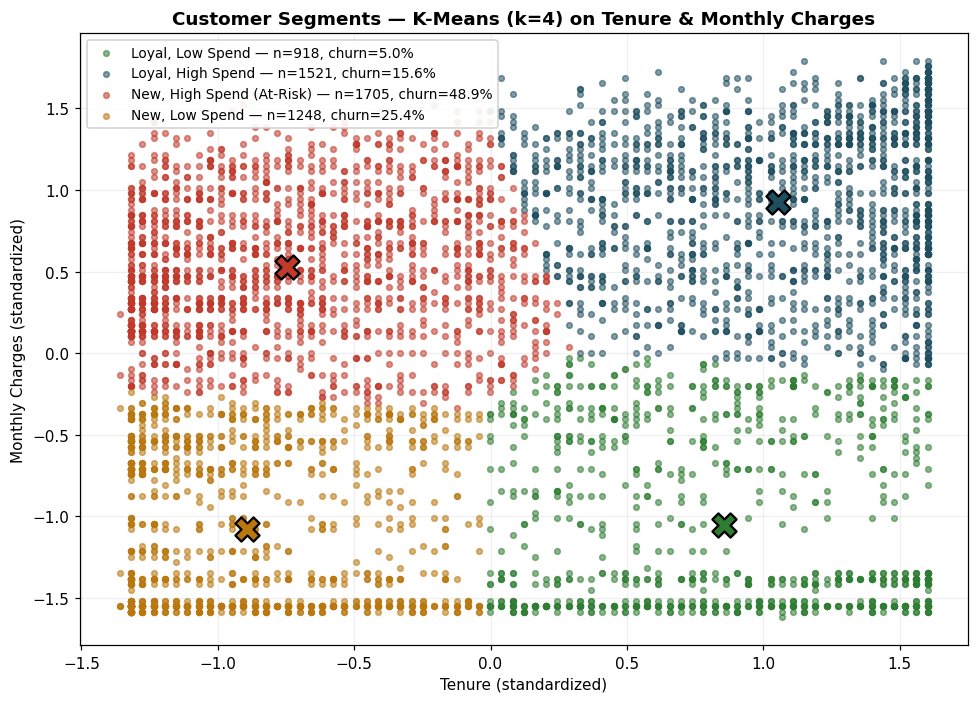

In [10]:
colors = {0: '#2E7D32', 1: '#1F4E5F', 2: '#C0392B', 3: '#B9770E'}

fig, ax = plt.subplots(figsize=(9, 6.5))
for c in sorted(results['cluster'].unique()):
    sub = results[results['cluster'] == c]
    churn_rate = sub['Churn'].mean() * 100
    ax.scatter(sub['tenure'], sub['MonthlyCharges'], s=14, alpha=0.55,
               color=colors[c],
               label=f"{cluster_labels_map[c]} \u2014 n={len(sub)}, churn={churn_rate:.1f}%")

# Mark the centroids
for c, center in enumerate(kmeans_final.cluster_centers_):
    ax.scatter(center[0], center[1], marker='X', s=250,
               color=colors[c], edgecolor='black', linewidth=1.5, zorder=5)

ax.set_xlabel('Tenure (standardized)')
ax.set_ylabel('Monthly Charges (standardized)')
ax.set_title('Customer Segments \u2014 K-Means (k=4) on Tenure & Monthly Charges', fontweight='bold')
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('cluster_visualization.png', dpi=160)
plt.show()

## 9. Save outputs

- `cluster_assignments.csv` — every training customer with their assigned cluster and
  churn label.
- `kmeans_model.pkl` — the trained model itself.

In [11]:
import pickle

results.to_csv('cluster_assignments.csv', index=False)

with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans_final, f)

print("Saved cluster_assignments.csv and kmeans_model.pkl")

Saved cluster_assignments.csv and kmeans_model.pkl


## Summary

- **Algorithm:** K-Means, chosen for scalability and because both features are continuous
- **Optimal k:** 4, confirmed by both the elbow method and silhouette score
- **Segments found:** Loyal/Low Spend, Loyal/High Spend, New/High Spend (At-Risk), New/Low Spend
- **Headline insight:** the New, High Spend segment churns at ~49%, far above the other
  three segments — this is the group to prioritise in retention recommendations